# EV Charging with **Stochastic Demand** — Simulation & RL

Same setup as the base notebook, but the next day's energy demand is now **random**:
$D \sim \mathcal{N}(\mu,\ \sigma)$ kWh, drawn once per day and **not** known while charging.

This turns the deterministic puzzle into a genuinely stochastic, **risk-averse** control problem,
and it forces two fixes: the benchmark and the evaluation must use the **expected** cost
(integrating the penalty over the demand distribution) instead of a single feasibility test.

**Notebook outline**
1. The problem as an MDP
2. Configuration & cost function
3. Gymnasium environment (random demand)
4. Optimal policy (expected-cost benchmark)
5. Monte Carlo Control
6. Q-learning

In [29]:
# # # Setup # # #
import os
import itertools
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from scipy.stats import norm          # for P(demand > soc) in the expected cost

# Switch to the project root (folder containing pyproject.toml) so paths are robust
_here = Path.cwd()
for _p in [_here, *_here.parents]:
    if (_p / "pyproject.toml").exists():
        os.chdir(_p)
        break
print("Working directory:", os.getcwd())

np.random.seed(42)

Working directory: /Users/hendrik/Coding/Master/AAA/AAA_TA_2026


## 1. The problem as an MDP

- **State** $s_t = (\text{SOC}_t,\ t)$ — battery charge (kWh) and the step index $t \in \{0,\dots,N-1\}$.
  The demand is **not** part of the state (it is unknown until departure).
- **Actions** $a$: charge at `zero` / `low` / `medium` / `high` power.
- **Dynamics (deterministic):** $\text{SOC}_{t+1} = \min(\text{SOC}_t + p_a\,\Delta t,\ \text{cap})$.
- **Cost of one step:** $cost(t) = \alpha_t \cdot e^{p_t/p_{\max}} \cdot (p_t\,\Delta t)$
  — higher charging power costs disproportionately more per kWh.
- **Random demand:** at departure a demand $D \sim \mathcal{N}(\mu, \sigma)$ kWh is drawn. The reward gets
  a **large penalty** if the battery falls short: $\text{reward} \mathrel{-}= \text{PENALTY}$ when $\text{SOC} < D$.

Because $D$ is random, the terminal reward is stochastic. Its expectation is a **smooth** ramp
instead of a hard cliff:

$$\mathbb{E}[\text{penalty}\mid \text{SOC}] = \text{PENALTY}\cdot P(D > \text{SOC}) = \text{PENALTY}\cdot\big(1-\Phi(\tfrac{\text{SOC}-\mu}{\sigma})\big).$$

The diagram already reflects this: the departure step branches on the drawn demand.

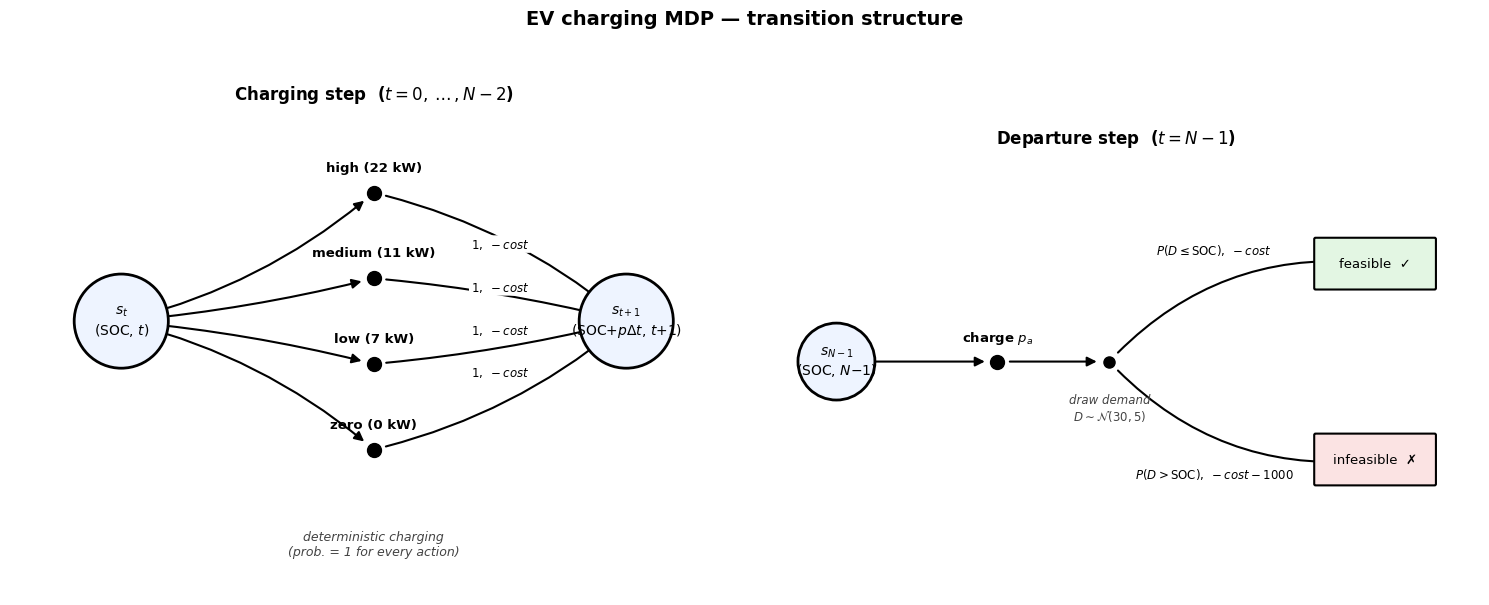

In [30]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# MDP transition diagram                  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, FancyBboxPatch

# ---- drawing helpers ---------------------------------------------------------
def state_node(ax, xy, label, r=0.55, fc="#eef4ff"):
    ax.add_patch(Circle(xy, r, fc=fc, ec="black", lw=2, zorder=3))
    ax.text(*xy, label, ha="center", va="center", fontsize=10, zorder=4)
    return xy

def action_dot(ax, xy, label=None, dy=0.22):
    ax.plot(*xy, "o", color="black", ms=10, zorder=3)
    if label:
        ax.text(xy[0], xy[1] + dy, label, ha="center", va="bottom",
                fontsize=9.5, fontweight="bold", zorder=4)

def edge(ax, a, b, rad=0.0, label=None, lxy=None, color="black", ls="-"):
    ax.add_patch(FancyArrowPatch(
        a, b, connectionstyle=f"arc3,rad={rad}", arrowstyle="-|>",
        mutation_scale=14, lw=1.5, color=color, ls=ls,
        shrinkA=9, shrinkB=9, zorder=2))
    if label and lxy:
        ax.text(*lxy, label, fontsize=8.5, ha="center", va="center", zorder=5,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none"))

def terminal_box(ax, xy, label, fc):
    ax.add_patch(FancyBboxPatch((xy[0] - 0.85, xy[1] - 0.35), 1.7, 0.7,
                 boxstyle="round,pad=0.02", fc=fc, ec="black", lw=1.5, zorder=3))
    ax.text(*xy, label, ha="center", va="center", fontsize=9.5, zorder=4)

# ---- figure ------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5))

ACTIONS = [("high (22 kW)", 5.0), ("medium (11 kW)", 4.0),
           ("low (7 kW)", 3.0), ("zero (0 kW)", 2.0)]

# ============================ Panel 1: charging step =========================
s_t   = state_node(ax1, (1.3, 3.5), "$s_t$\n(SOC, $t$)")
s_t1  = state_node(ax1, (7.2, 3.5), "$s_{t+1}$\n(SOC+$p\\Delta t$, $t{+}1$)")

for name, y in ACTIONS:
    dot = (4.25, y)
    action_dot(ax1, dot, name)
    edge(ax1, s_t, dot, rad=0.12 * (y - 3.5) / 1.5)               # state -> action
    edge(ax1, dot, s_t1, rad=-0.12 * (y - 3.5) / 1.5,             # action -> next state
         label="$1,\\ -cost$", lxy=((dot[0] + 7.2) / 2, (y + 3.5) / 2 + 0.15))

ax1.text(4.25, 0.9, "deterministic charging\n(prob. = 1 for every action)",
         ha="center", va="center", fontsize=9, style="italic", color="#444")
ax1.set_title("Charging step  ($t = 0,\\dots,N-2$)", fontsize=12, fontweight="bold")

# ============================ Panel 2: departure step ========================
s_N  = state_node(ax2, (1.2, 3.0), "$s_{N-1}$\n(SOC, $N{-}1$)")
act  = (3.5, 3.0)
action_dot(ax2, act, "charge $p_a$")
edge(ax2, s_N, act)

chance = (5.1, 3.0)
ax2.plot(*chance, "o", color="black", ms=8, zorder=3)
edge(ax2, act, chance)
ax2.text(5.1, 2.55, "draw demand\n$D\\sim\\mathcal{N}(30,5)$", ha="center",
         va="top", fontsize=8.5, style="italic", color="#444")

feas   = (8.9, 4.4)
infeas = (8.9, 1.6)
terminal_box(ax2, feas,   "feasible  ✓", "#e3f6e3")
terminal_box(ax2, infeas, "infeasible  ✗", "#fbe3e3")
edge(ax2, chance, feas,   rad=-0.25,
     label="$P(D \\leq \\mathrm{SOC}),\\ -cost$", lxy=(6.6, 4.6))
edge(ax2, chance, infeas, rad=0.25,
     label="$P(D > \\mathrm{SOC}),\\ -cost-1000$", lxy=(6.6, 1.4))
ax2.set_title("Departure step  ($t = N-1$)", fontsize=12, fontweight="bold")

# ---- cosmetics ---------------------------------------------------------------
for ax, xlim in ((ax1, (0, 8.5)), (ax2, (0, 10.4))):
    ax.set_xlim(*xlim)
    ax.set_ylim(0.3, 6)
    ax.set_aspect("equal")
    ax.axis("off")

fig.suptitle("EV charging MDP — transition structure", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig("data/mdp_graph.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Configuration & cost function

Cost per 15-min step:
  zero    ( 0 kW): 0.00
  low     ( 7 kW): 1.02
  medium  (11 kW): 2.15
  high    (22 kW): 9.62


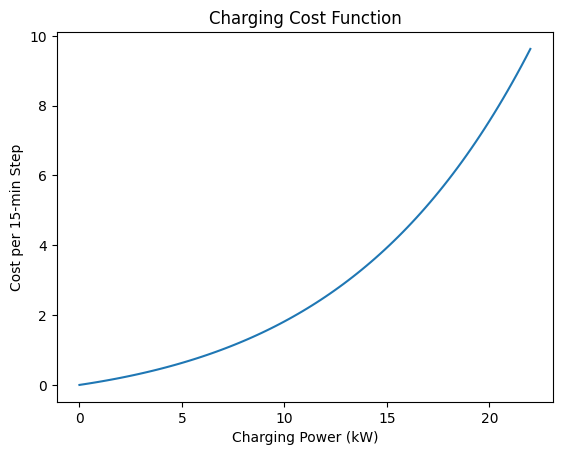

In [31]:
# # # Configuration # # #
N_STEPS  = 8            # 8 x 15-min steps = 2 h at home (2pm -> 4pm)
DELTA_T  = 0.25         # hours per step
SOC_INIT_MIN = 5.0          # kWh in the battery at arrival
SOC_INIT_MAX = 15.0         # kWh in the battery at arrival
CAPACITY = 60.0         # kWh battery capacity

DEMAND_MU    = 30.0     # kWh, mean next-day demand
DEMAND_SIGMA = 5.0      # kWh, demand std-dev   ->   demand ~ Normal(mu, sigma)

P_MAX = 22              # kW, fastest charger
X = 5.0                 # how much more expensive per-kWh charging is at full power vs. trickle. x = 2 means at 22 kW you pay double the base rate per kWh.
CHARGING_LEVELS = {"zero": 0, "low": 7, "medium": 11, "high": 22}  # kW
ACTIONS = list(CHARGING_LEVELS)           # action names; list index = action id
POWERS  = list(CHARGING_LEVELS.values())  # charging power (kW) per action id

ALPHA   = 0.35          # $/kWh electricity price
PENALTY = 100.0        # large cost if the battery is too low at departure


def charging_cost(power):
    """Cost of charging at `power` kW for one 15-min step."""
    if power == 0:
        return 0.0
    return 0.25 * ALPHA * power * X ** (power / P_MAX)


print("Cost per 15-min step:")
for name, p in CHARGING_LEVELS.items():
    print(f"  {name:7s} ({p:2d} kW): {charging_cost(p):.2f}")

# plot of the cost function with labels
powers = np.linspace(0, P_MAX, 100)
costs = [charging_cost(p) for p in powers]
plt.plot(powers, costs)
plt.xlabel("Charging Power (kW)")
plt.ylabel("Cost per 15-min Step")
plt.title("Charging Cost Function")
plt.show()

## 3. Gymnasium environment (random demand)

The only change from the base notebook: `reset` **draws a fresh demand** from
$\mathcal{N}(\mu, \sigma)$, and the departure penalty is checked against that realized demand.

In [32]:
# # # Gymnasium environment (stochastic demand + random initial SOC) # # #
class EVChargingEnv(gym.Env):
    """Charge an EV over N_STEPS steps to meet a RANDOM daily demand.

    State  : (soc, time_step)          # demand is hidden, not part of the state
    Action : 0=zero, 1=low, 2=medium, 3=high  (charging power)
    Reward : -charging_cost each step; -PENALTY at the end if soc < demand
    """

    def __init__(self):
        super().__init__()
        self.action_space = spaces.Discrete(len(POWERS))
        self.observation_space = spaces.MultiDiscrete([int(CAPACITY * 4) + 1, N_STEPS])

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # random start SOC, snapped to the 0.25 kWh grid so the tabular state space stays discrete
        self.soc = round(np.random.uniform(SOC_INIT_MIN, SOC_INIT_MAX) * 4) / 4
        self.t = 0
        self.demand = min(max(0.0, np.random.normal(DEMAND_MU, DEMAND_SIGMA)), CAPACITY)  # drawn once, hidden
        return self._state(), {}

    def _state(self):
        return (round(self.soc, 2), self.t)   # soc is always a multiple of 0.25

    def step(self, action):
        power = POWERS[action]
        self.soc = min(self.soc + power * DELTA_T, CAPACITY)
        reward = -charging_cost(power)
        self.t += 1
        terminated = self.t >= N_STEPS
        if terminated and self.soc < self.demand:     # this day's demand not met
            reward -= PENALTY
        return self._state(), reward, terminated, False, {}


# Sanity check: one episode with random actions
env = EVChargingEnv()
state, _ = env.reset(seed=0)
start_soc = env.soc
done, total = False, 0.0
while not done:
    state, r, term, trunc, _ = env.step(env.action_space.sample())
    total += r
    done = term or trunc
print(f"Random policy -> start SOC {start_soc:.2f}, final SOC {env.soc:.1f} kWh, demand {env.demand:.1f} kWh, reward {total:.1f}")

Random policy -> start SOC 8.75, final SOC 21.5 kWh, demand 24.4 kWh, reward -109.6


## 4. Optimal policy (expected-cost benchmark)

**Fix #1 — the benchmark.** A schedule's cost is an *expectation* over the random demand: since the
dynamics are deterministic, a schedule has one final SOC, and its expected penalty is
$\text{PENALTY}\cdot P(D > \text{SOC}) = \text{PENALTY}\,(1-\Phi(\tfrac{\text{SOC}-\mu}{\sigma}))$.

Because the **initial SOC is now random too**, the best schedule depends on where we start, so the
optimum is a *policy*, not a single schedule. The benchmark `best_cost` is therefore the **expected
optimal cost, averaged over the initial-SOC distribution**.

In [33]:
# # # Ground-truth optimum with a RANDOM initial SOC # # #
# The best schedule now depends on the SOC we start from, so the benchmark is the EXPECTED
# optimal cost, averaged over the initial-SOC distribution U(SOC_INIT_MIN, SOC_INIT_MAX).
SOC_EVAL_GRID = np.linspace(SOC_INIT_MIN, SOC_INIT_MAX, 21)   # grid over the random start SOC


def schedule_expected_cost(actions, soc_init):
    """Expected cost of one schedule from a given start SOC (charging + expected penalty)."""
    soc, charge = soc_init, 0.0
    for a in actions:
        soc = min(soc + POWERS[a] * DELTA_T, CAPACITY)
        charge += charging_cost(POWERS[a])
    p_short = 1.0 - norm.cdf((soc - DEMAND_MU) / DEMAND_SIGMA)      # P(demand > soc)
    return charge + PENALTY * p_short, soc


# Pre-compute each schedule's total energy and charging cost once (independent of the start SOC),
# so we can evaluate every start SOC by a fast vectorised minimisation.
_SEQS   = np.array(list(itertools.product(range(4), repeat=N_STEPS)))       # (4^8, 8)
_ENERGY = (np.array(POWERS)[_SEQS] * DELTA_T).sum(axis=1)                   # kWh added per schedule
_CHARGE = np.array([charging_cost(p) for p in POWERS])[_SEQS].sum(axis=1)   # $ charging per schedule


def optimal_schedule(soc_init):
    """Cheapest schedule (in expectation) for a given start SOC, and its cost / final SOC."""
    soc   = np.minimum(soc_init + _ENERGY, CAPACITY)
    total = _CHARGE + PENALTY * (1.0 - norm.cdf((soc - DEMAND_MU) / DEMAND_SIGMA))
    i = int(total.argmin())
    return _SEQS[i], float(total[i]), float(soc[i])


# The yardstick: expected optimal cost averaged over the initial-SOC distribution
best_cost = float(np.mean([optimal_schedule(s0)[1] for s0 in SOC_EVAL_GRID]))
print(f"Optimal EXPECTED cost, averaged over start SOC in "
      f"[{SOC_INIT_MIN:.0f}, {SOC_INIT_MAX:.0f}] kWh: {best_cost:.2f}\n")

print("The optimum depends on where we start:")
for s0 in (SOC_INIT_MIN, 0.5 * (SOC_INIT_MIN + SOC_INIT_MAX), SOC_INIT_MAX):
    seq, cost, soc = optimal_schedule(s0)
    assert abs(schedule_expected_cost(list(seq), s0)[0] - cost) < 1e-9   # matches the readable fn
    print(f"  start SOC {s0:4.1f} -> cost {cost:5.2f}, final SOC {soc:5.2f}: {[ACTIONS[a] for a in seq]}")

Optimal EXPECTED cost, averaged over start SOC in [5, 15] kWh: 39.10

The optimum depends on where we start:
  start SOC  5.0 -> cost 52.59, final SOC 38.00: ['medium', 'medium', 'medium', 'medium', 'high', 'high', 'high', 'high']
  start SOC 10.0 -> cost 38.84, final SOC 37.50: ['medium', 'medium', 'medium', 'medium', 'medium', 'medium', 'high', 'high']
  start SOC 15.0 -> cost 25.29, final SOC 37.00: ['medium', 'medium', 'medium', 'medium', 'medium', 'medium', 'medium', 'medium']


**Fix #2 — the evaluation.** A greedy policy is deterministic, so its final SOC is fixed and
we can score it by its **expected** cost (charging cost + $\text{PENALTY}\cdot P(D>\text{SOC})$) — no noisy
single-episode sampling. The helpers below use this for both the printed schedule and the
learning curves.

In [34]:
# # # Shared helpers (used by both learning methods) # # #
def epsilon_greedy(Q, state, eps, n_actions):
    if np.random.rand() < eps:
        return np.random.randint(n_actions)   # explore: random action
    return int(np.argmax(Q[state]))           # exploit: current best action


def expected_cost(final_soc, charge):
    """Charging cost + expected departure penalty (demand integrated out)."""
    return charge + PENALTY * (1.0 - norm.cdf((final_soc - DEMAND_MU) / DEMAND_SIGMA))


def _greedy_from(env, Q, soc_init):
    """Deterministic greedy rollout from a fixed start SOC; returns (final_soc, charge)."""
    env.reset()
    env.soc, env.t = float(soc_init), 0
    charge = 0.0
    while env.t < N_STEPS:
        a = int(np.argmax(Q[env._state()]))
        charge += charging_cost(POWERS[a])
        env.step(a)
    return env.soc, charge


def greedy_cost(env, Q):
    """Expected cost of the greedy policy, averaged over the initial-SOC distribution."""
    return float(np.mean([expected_cost(*_greedy_from(env, Q, s0)) for s0 in SOC_EVAL_GRID]))


def greedy_rollout(env, Q, label):
    """Print the greedy schedule from a representative start SOC and report the expected cost
    averaged over the whole initial-SOC range."""
    s0 = 0.5 * (SOC_INIT_MIN + SOC_INIT_MAX)
    env.reset()
    env.soc, env.t = float(s0), 0
    charge = 0.0
    print(f"{label} - greedy schedule from start SOC {s0:.1f} kWh:")
    while env.t < N_STEPS:
        a = int(np.argmax(Q[env._state()]))
        soc_before = env.soc
        charge += charging_cost(POWERS[a])
        env.step(a)
        print(f"  step {env.t - 1}: SOC {soc_before:5.2f} --{ACTIONS[a]:7s}({POWERS[a]:2d} kW)--> {env.soc:5.2f}")
    final_soc = env.soc                                       # capture BEFORE greedy_cost resets env
    p_short = 1.0 - norm.cdf((final_soc - DEMAND_MU) / DEMAND_SIGMA)
    avg = greedy_cost(env, Q)                                 # averaged over the start-SOC range
    print(f"  final SOC {final_soc:.2f} kWh | P(demand not met) {p_short:.1%}")
    print(f"  expected cost averaged over start SOC: {avg:.2f}   vs optimum {best_cost:.2f}")
    return avg


def plot_learning_curve(curve, title, eval_every):
    """Plot the greedy policy's EXPECTED cost against training episodes (log scale)."""
    x = np.arange(len(curve)) * eval_every
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x, curve, label="greedy-policy expected cost")
    ax.axhline(best_cost, ls="--", color="green", label=f"optimum ({best_cost:.1f})")
    ax.set_yscale("log")
    ax.set_xlabel("episode")
    ax.set_ylabel("expected cost of greedy policy ($, log scale)")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.show()

## 5. Monte Carlo Control

Identical algorithm to the base notebook — **first-visit Monte Carlo control** with a fixed
exploration rate $\varepsilon$. Nothing about the agent changes; only the environment is now
stochastic, so each episode's return carries a randomly-sampled penalty. Monte Carlo simply
averages over those draws.

> $\varepsilon$ must still be large enough to explore; too small an $\varepsilon$ can leave the
> agent stuck under-charging before it ever experiences the penalty.

In [35]:
# # # Monte Carlo Control (first-visit, epsilon-greedy) # # #
def train_mc(env, n_episodes=80000, gamma=1.0, epsilon=0.3, eval_every=400):
    n_actions = env.action_space.n
    Q      = defaultdict(lambda: np.zeros(n_actions))   # action-value estimates
    counts = defaultdict(lambda: np.zeros(n_actions))   # visit counts (for the average)
    curve  = []                                          # greedy-policy expected cost during training

    for ep in range(n_episodes):
        # 1) play one episode (demand is sampled inside env.reset)
        state, _ = env.reset()
        episode, done = [], False
        while not done:
            a = epsilon_greedy(Q, state, epsilon, n_actions)
            nxt, r, term, trunc, _ = env.step(a)
            episode.append((state, a, r))
            state, done = nxt, term or trunc

        # 2) update Q towards the return G (running average)
        G = 0.0
        for state, a, r in reversed(episode):
            G = r + gamma * G
            counts[state][a] += 1
            Q[state][a] += (G - Q[state][a]) / counts[state][a]

        if ep % eval_every == 0:
            curve.append(greedy_cost(env, Q))
    return Q, curve


Q_mc, curve_mc = train_mc(env, epsilon=0.3)
print(f"Training done. Visited {len(Q_mc)} states.")

Training done. Visited 881 states.


### Results

With **random** demand the optimum changes character. Charging only to the mean demand leaves a
**50 %** chance of falling short — a large expected penalty — so the agent must **hedge**.
Because the shortfall penalty dwarfs the charging cost, the risk-averse optimum is to **charge at
full power on every step** (pushing the SOC well above the mean, leaving only a tiny shortfall
probability), and Monte Carlo learns exactly this.

Contrast with the fixed-demand notebook: there the hard feasibility cliff made MC stay
conservative and miss the optimum. Here the cliff is *smoothed* into the expected penalty
$\text{PENALTY}\cdot P(D>\text{SOC})$, and the optimum **is** the safe high-charging policy — so MC lands
right on it.

Monte Carlo - greedy schedule from start SOC 10.0 kWh:
  step 0: SOC 10.00 --high   (22 kW)--> 15.50
  step 1: SOC 15.50 --high   (22 kW)--> 21.00
  step 2: SOC 21.00 --medium (11 kW)--> 23.75
  step 3: SOC 23.75 --medium (11 kW)--> 26.50
  step 4: SOC 26.50 --medium (11 kW)--> 29.25
  step 5: SOC 29.25 --low    ( 7 kW)--> 31.00
  step 6: SOC 31.00 --high   (22 kW)--> 36.50
  step 7: SOC 36.50 --medium (11 kW)--> 39.25
  final SOC 39.25 kWh | P(demand not met) 3.2%
  expected cost averaged over start SOC: 40.27   vs optimum 39.10


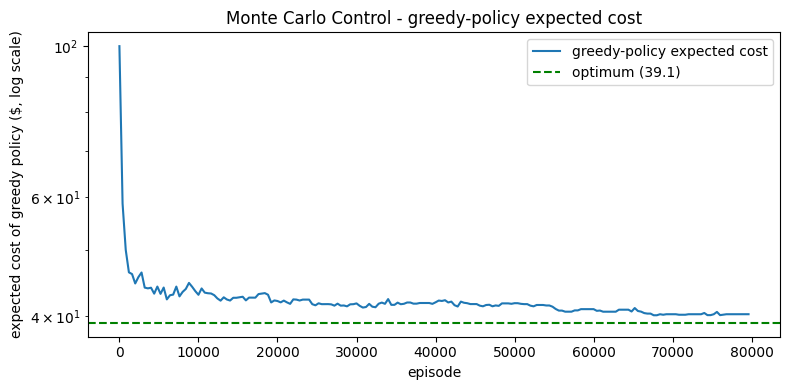

In [36]:
# # # Monte Carlo - results # # #
mc_cost = greedy_rollout(env, Q_mc, "Monte Carlo")
plot_learning_curve(curve_mc, "Monte Carlo Control - greedy-policy expected cost", eval_every=400)

## 6. Q-learning

The off-policy TD update:

$$Q(s,a) \;\leftarrow\; Q(s,a) + \alpha\,\big[\,r + \gamma\,\max_{a'} Q(s',a') - Q(s,a)\,\big]$$

It bootstraps from the greedy action. We use a **running-average** step size
$\alpha = 1/N(s,a)$ (exactly as Monte Carlo averages its returns). This matters with random
demand: a *constant* $\alpha$ is an exponential moving average that keeps **forgetting** the rare
large penalty (a rare event once the battery is near full), so it under-estimates the risk and
under-charges. The running average estimates that rare penalty without bias.

In [39]:
# # # Q-learning (off-policy TD control, running-average step size) # # #
def train_qlearning(env, n_episodes=1500000, gamma=1.0, epsilon=0.3, eval_every=400):
    n_actions = env.action_space.n
    Q      = defaultdict(lambda: np.zeros(n_actions))
    counts = defaultdict(lambda: np.zeros(n_actions))   # N(s,a) -> step size 1/N
    curve  = []

    for ep in range(n_episodes):
        state, _ = env.reset()
        done = False
        while not done:
            a = epsilon_greedy(Q, state, epsilon, n_actions)
            nxt, r, term, trunc, _ = env.step(a)
            done = term or trunc
            best_next = 0.0 if done else np.max(Q[nxt])   # bootstrap from the greedy action
            counts[state][a] += 1
            Q[state][a] += (r + gamma * best_next - Q[state][a]) / counts[state][a]
            state = nxt

        if ep % eval_every == 0:
            curve.append(greedy_cost(env, Q))
    return Q, curve


Q_ql, curve_ql = train_qlearning(env, epsilon=0.3)
print(f"Training done. Visited {len(Q_ql)} states.")

Training done. Visited 898 states.


### Results

Q-learning reaches the **same** risk-averse optimum (charge to the top). With stochastic demand
the two methods agree, because the optimal policy has a wide safety margin — there is no tight,
exploration-sensitive path to get wrong, which is what separated them in the fixed-demand case.
The catch is variance: estimating a rare, large penalty needs enough samples, so both methods use
many episodes and an averaging ($1/N$) step size.

The learning curves plot the greedy policy's **expected** cost (demand integrated out), so they
stay smooth despite the randomly-sampled penalties seen during training.

Q-learning - greedy schedule from start SOC 10.0 kWh:
  step 0: SOC 10.00 --medium (11 kW)--> 12.75
  step 1: SOC 12.75 --medium (11 kW)--> 15.50
  step 2: SOC 15.50 --medium (11 kW)--> 18.25
  step 3: SOC 18.25 --medium (11 kW)--> 21.00
  step 4: SOC 21.00 --medium (11 kW)--> 23.75
  step 5: SOC 23.75 --medium (11 kW)--> 26.50
  step 6: SOC 26.50 --high   (22 kW)--> 32.00
  step 7: SOC 32.00 --high   (22 kW)--> 37.50
  final SOC 37.50 kWh | P(demand not met) 6.7%
  expected cost averaged over start SOC: 40.56   vs optimum 39.10


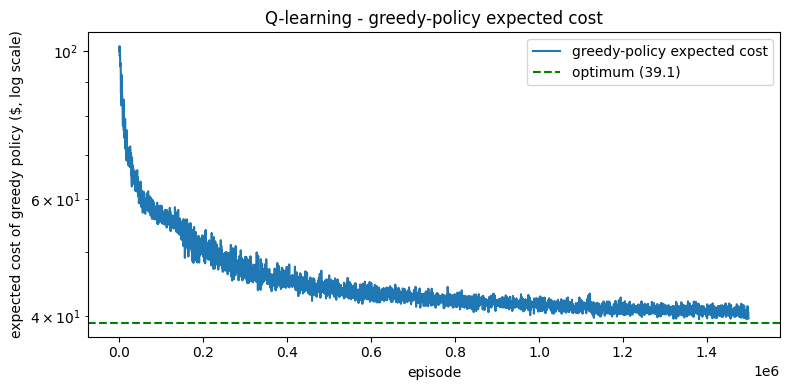

In [40]:
# # # Q-learning - results # # #
ql_cost = greedy_rollout(env, Q_ql, "Q-learning")
plot_learning_curve(curve_ql, "Q-learning - greedy-policy expected cost", eval_every=400)